# ODE Analysis Notebook
Practical ODE models, numerical solvers, stability checks, parameter sweeps, and a Protocol 1 comparison.

In [9]:
# Imports and notebook helpers
from pathlib import Path
import json
import pickle
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.integrate import odeint, solve_ivp
from scipy.optimize import least_squares

sns.set_theme(style='whitegrid')
FIGDIR = Path('ode_results')
FIGDIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    path = FIGDIR / name
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Saved figure: {path}')

def show_table(df, n=5):
    try:
        from IPython.display import display
        display(df.head(n))
    except Exception:
        print(df.head(n).to_string(index=False))

In [10]:
# ODE models and analytic benchmark
import math

def exp_decay_analytic(t, y0, k):
    return y0 * np.exp(-k * np.asarray(t))

def exp_decay(t, y, params):
    k = params.get('k', 1.0)
    return -k * y

def damped_osc(t, y, params):
    omega = params.get('omega', 1.0)
    zeta = params.get('zeta', 0.1)
    x, v = y
    return [v, -2.0 * zeta * omega * v - omega ** 2 * x]

def lotka_volterra(t, y, params):
    a = params.get('prey_birth', 1.0)
    b = params.get('predation_rate', 0.1)
    c = params.get('predator_eff', 0.1)
    d = params.get('predator_death', 1.0)
    prey, predator = y
    return [a * prey - b * prey * predator, c * b * prey * predator - d * predator]

def robertson(t, y, params=None):
    y1, y2, y3 = y
    return [-0.04 * y1 + 1e4 * y2 * y3, 0.04 * y1 - 1e4 * y2 * y3 - 3e7 * y2 ** 2, 3e7 * y2 ** 2]

print('Model helpers ready')

Model helpers ready


Observed order ~ 4.02
Saved figure: ode_results\convergence_exp.png


Observed order ~ 4.02
Saved figure: ode_results\convergence_exp.png


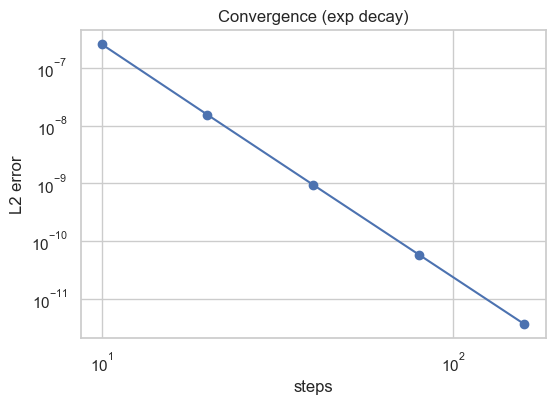

In [11]:
# Numerical solver wrappers and RK4 convergence
def run_solve_ivp(f, y0, t_span, params=None, t_eval=None, method='RK45', rtol=1e-6, atol=1e-9):
    params = params or {}
    fun = lambda t, y: f(t, y, params)
    sol = solve_ivp(fun, t_span, np.atleast_1d(y0), method=method, t_eval=t_eval, rtol=rtol, atol=atol)
    return sol.t, sol.y, sol

def run_odeint(f, y0, t, params=None):
    params = params or {}
    return odeint(lambda y, tt: f(tt, y, params), y0, t).T

def rk4_step(f, t, y, h, params=None):
    params = params or {}
    k1 = np.asarray(f(t, y, params))
    k2 = np.asarray(f(t + 0.5 * h, y + 0.5 * h * k1, params))
    k3 = np.asarray(f(t + 0.5 * h, y + 0.5 * h * k2, params))
    k4 = np.asarray(f(t + h, y + h * k3, params))
    return y + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def rk4_integrate(f, y0, t_span, n_steps, params=None):
    t0, tf = t_span
    h = (tf - t0) / n_steps
    y = np.atleast_1d(y0).astype(float)
    ts = [t0]
    ys = [y.copy()]
    t = t0
    for _ in range(n_steps):
        y = rk4_step(f, t, y, h, params)
        t += h
        ts.append(t)
        ys.append(y.copy())
    return np.array(ts), np.array(ys).T

def convergence_test_exp():
    steps = np.array([10, 20, 40, 80, 160])
    errors = []
    # Measure error at the RK4 integrator nodes (avoid interpolation error)
    for n in steps:
        ts, ys = rk4_integrate(lambda t, y, p: exp_decay(t, y, {'k': 1.0}), 1.0, (0.0, 1.0), int(n))
        y_ref_at_ts = exp_decay_analytic(ts, 1.0, 1.0)
        errors.append(np.linalg.norm(ys[0] - y_ref_at_ts, ord=2) / np.sqrt(len(ts)))
    # observed order is the negative slope of log(error) vs log(steps)
    order = -np.polyfit(np.log(steps), np.log(errors), 1)[0]
    print(f'Observed order ~ {order:.2f}')
    plt.figure(figsize=(6, 4))
    plt.loglog(steps, errors, '-o')
    plt.xlabel('steps')
    plt.ylabel('L2 error')
    plt.title('Convergence (exp decay)')
    savefig('convergence_exp.png')

convergence_test_exp()

Saved figure: ode_results\lv_phase.png
Saved figure: ode_results\lv_nullclines.png
Equilibrium: (99.99999999999999, 10.0)
Eigenvalues: [0.+1.j 0.-1.j]


Saved figure: ode_results\lv_phase.png
Saved figure: ode_results\lv_nullclines.png
Equilibrium: (99.99999999999999, 10.0)
Eigenvalues: [0.+1.j 0.-1.j]


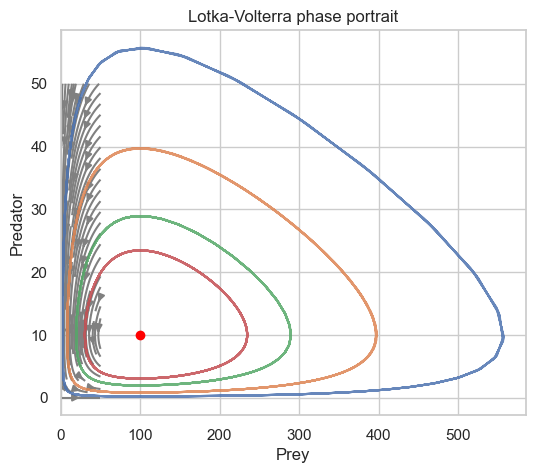

Saved figure: ode_results\lv_phase.png
Saved figure: ode_results\lv_nullclines.png
Equilibrium: (99.99999999999999, 10.0)
Eigenvalues: [0.+1.j 0.-1.j]


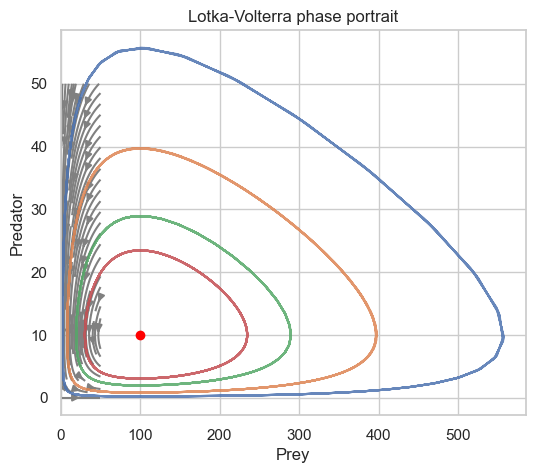

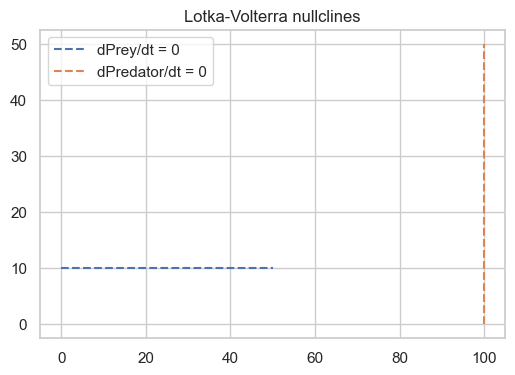

In [12]:
# Phase portrait, nullclines, and linear stability
params = {'prey_birth': 1.0, 'predation_rate': 0.1, 'predator_eff': 0.1, 'predator_death': 1.0}
x = np.linspace(0, 50, 25)
y = np.linspace(0, 50, 25)
X, Y = np.meshgrid(x, y)
U = np.zeros_like(X)
V = np.zeros_like(Y)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        dx, dy = lotka_volterra(0, [X[i, j], Y[i, j]], params)
        U[i, j] = dx
        V[i, j] = dy

plt.figure(figsize=(6, 5))
plt.streamplot(X, Y, U, V, density=1.0, color='gray')
for ic in ([5, 2], [10, 5], [20, 8], [35, 15]):
    t_eval = np.linspace(0, 50, 600)
    _, sol, _ = run_solve_ivp(lotka_volterra, ic, (0, 50), params=params, t_eval=t_eval)
    plt.plot(sol[0], sol[1], alpha=0.85)
prey_nullcline = params['prey_birth'] / params['predation_rate']
predator_nullcline = params['predator_death'] / (params['predator_eff'] * params['predation_rate'])
plt.scatter([predator_nullcline], [prey_nullcline], c='red', zorder=5)
plt.xlabel('Prey')
plt.ylabel('Predator')
plt.title('Lotka-Volterra phase portrait')
savefig('lv_phase.png')

plt.figure(figsize=(6, 4))
plt.plot(x, np.full_like(x, prey_nullcline), '--', label='dPrey/dt = 0')
plt.plot(np.full_like(y, predator_nullcline), y, '--', label='dPredator/dt = 0')
plt.legend()
plt.title('Lotka-Volterra nullclines')
savefig('lv_nullclines.png')

def jacobian_lv(eq, params):
    prey_eq, predator_eq = eq
    a = params['prey_birth']
    b = params['predation_rate']
    c = params['predator_eff']
    d = params['predator_death']
    return np.array([[a - b * predator_eq, -b * prey_eq], [c * b * predator_eq, c * b * prey_eq - d]])

eq = (predator_nullcline, prey_nullcline)
J = jacobian_lv(eq, params)
w, v = np.linalg.eig(J)
print('Equilibrium:', eq)
print('Eigenvalues:', w)

,b,prey_mean_tail,predator_mean_tail
0,0.03,408.704881,29.743774
1,0.05,226.136604,22.710356
2,0.07,153.725581,14.874373
3,0.09,108.257744,10.348304
4,0.11,90.020962,8.985166


,b,prey_mean_tail,predator_mean_tail
0,0.03,408.704881,29.743774
1,0.05,226.136604,22.710356
2,0.07,153.725581,14.874373
3,0.09,108.257744,10.348304
4,0.11,90.020962,8.985166


Saved figure: ode_results\bifurcation_style_summary.png
Event times: []
RK45 time: 243.630s | BDF time: 0.058s


,b,prey_mean_tail,predator_mean_tail
0,0.03,408.704881,29.743774
1,0.05,226.136604,22.710356
2,0.07,153.725581,14.874373
3,0.09,108.257744,10.348304
4,0.11,90.020962,8.985166


Saved figure: ode_results\bifurcation_style_summary.png
Event times: []
RK45 time: 243.630s | BDF time: 0.058s


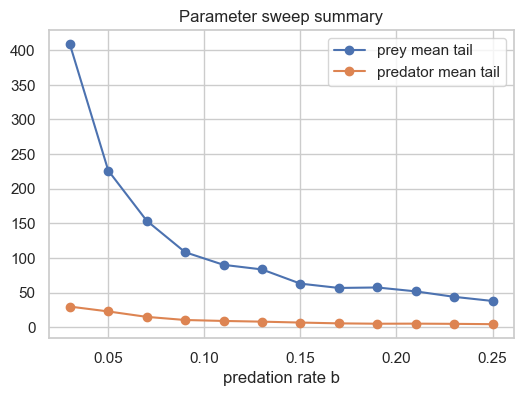

In [13]:
# Parameter sweep, event detection, and stiff-solver comparison
sweep = []
for b in np.linspace(0.03, 0.25, 12):
    sweep_params = {'prey_birth': 1.0, 'predation_rate': float(b), 'predator_eff': 0.1, 'predator_death': 1.0}
    t_eval = np.linspace(0, 120, 1200)
    _, sol, _ = run_solve_ivp(lotka_volterra, [10, 5], (0, 120), params=sweep_params, t_eval=t_eval)
    tail = slice(int(0.8 * sol.shape[1]), None)
    sweep.append({'b': b, 'prey_mean_tail': float(np.mean(sol[0, tail])), 'predator_mean_tail': float(np.mean(sol[1, tail]))})
sweep_df = pd.DataFrame(sweep)
show_table(sweep_df)
plt.figure(figsize=(6, 4))
plt.plot(sweep_df['b'], sweep_df['prey_mean_tail'], '-o', label='prey mean tail')
plt.plot(sweep_df['b'], sweep_df['predator_mean_tail'], '-o', label='predator mean tail')
plt.xlabel('predation rate b')
plt.legend()
plt.title('Parameter sweep summary')
savefig('bifurcation_style_summary.png')

def prey_threshold_event(t, y):
    return y[0] - 2.0
prey_threshold_event.terminal = True
prey_threshold_event.direction = -1

event_params = {'prey_birth': 1.0, 'predation_rate': 0.2, 'predator_eff': 0.1, 'predator_death': 1.0}
event_sol = solve_ivp(lambda t, y: lotka_volterra(t, y, event_params), (0, 80), [8, 4], events=prey_threshold_event)
print('Event times:', event_sol.t_events[0])

start = time.time()
_, _, sol_rk = run_solve_ivp(robertson, [1.0, 0.0, 0.0], (0, 1e3), method='RK45', rtol=1e-6, atol=1e-10)
rk_time = time.time() - start
start = time.time()
_, _, sol_bdf = run_solve_ivp(robertson, [1.0, 0.0, 0.0], (0, 1e3), method='BDF', rtol=1e-6, atol=1e-10)
bdf_time = time.time() - start
print(f'RK45 time: {rk_time:.3f}s | BDF time: {bdf_time:.3f}s')

Saved reproducibility metadata
Loaded: ..\src\models\results\protocol_1v1_10_27.csv
Columns: ['episode', 'reward', 'steps', 'eval_reward', 'outcome', 'prey_population', 'predator_population', 'avg_prey_energy', 'avg_predator_energy']
Saved figure: ode_results\protocol1_outcome_trend.png
Outcome counts: {'PREY_WIN': 2796, 'PREDATOR_WIN': 204}
Fitted params: [0.99996701 0.09999169 0.1000156  1.00005253]
Saved figure: ode_results\sensitivity_predation_rate.png


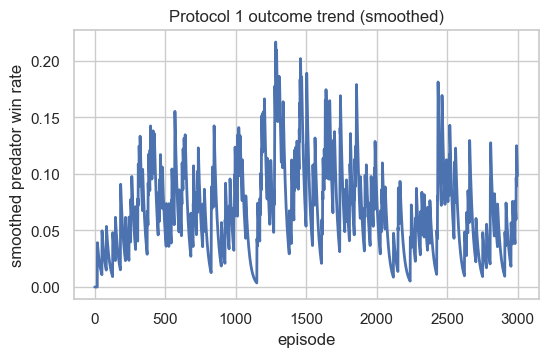

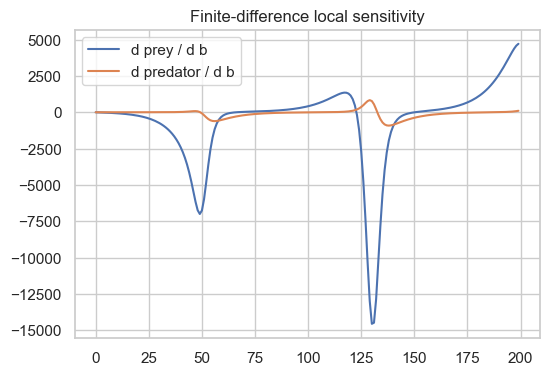

In [20]:
# Save/export, Protocol 1 comparison, and quick fit/sensitivity demo
metadata = {
    'seed': 42,
    'model': 'lotka_volterra',
    'params': {'prey_birth': 1.0, 'predation_rate': 0.1, 'predator_eff': 0.1, 'predator_death': 1.0},
}
with open(FIGDIR / 'experiment_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)
with open(FIGDIR / 'experiment_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print('Saved reproducibility metadata')

# Prefer the explicit protocol_1v1_10_27.csv file; fall back to candidate locations if missing
csv_path = Path('src/models/results/protocol_1v1_10_27.csv')
if not csv_path.exists():
    csv_candidates = [
        Path('src/models/results/protocol_1v1_10_27.csv'),
        Path('..') / 'src' / 'models' / 'results' / 'protocol_1v1_10_27.csv',
    ]
    csv_path = next((path for path in csv_candidates if path.exists()), None)
if csv_path is None:
    print('Protocol 1 CSV not found at expected locations')
else:
    rl_df = pd.read_csv(csv_path)
    print('Loaded:', csv_path)
    print('Columns:', list(rl_df.columns))
    if 'outcome' in rl_df.columns:
        outcome_map = {'PREDATOR_WIN': 1.0, 'PREY_WIN': 0.0, 'DRAW': 0.5}
        outcome_series = rl_df['outcome'].astype(str).str.upper().map(outcome_map)
        if outcome_series.isna().all():
            outcome_series = pd.to_numeric(rl_df['outcome'], errors='coerce')
        smoothed = outcome_series.ewm(span=50, adjust=False).mean()
        plt.figure(figsize=(6, 3.5))
        plt.plot(smoothed.values, linewidth=2.0)
        plt.xlabel('episode')
        plt.ylabel('smoothed predator win rate')
        plt.title('Protocol 1 outcome trend (smoothed)')
        savefig('protocol1_outcome_trend.png')
        print('Outcome counts:', rl_df['outcome'].value_counts().to_dict())

# Lightweight parameter fit and finite-difference sensitivity
true_params = {'prey_birth': 1.0, 'predation_rate': 0.1, 'predator_eff': 0.1, 'predator_death': 1.0}
t = np.linspace(0, 30, 80)
_, ys_true, _ = run_solve_ivp(lotka_volterra, [10, 5], (0, 30), params=true_params, t_eval=t)
y_obs = ys_true.T + 0.03 * np.random.randn(len(t), 2)

def residuals(params_vec, t, y_obs, y0):
    a, b, c, d = params_vec
    fit_params = {'prey_birth': a, 'predation_rate': b, 'predator_eff': c, 'predator_death': d}
    _, ys, _ = run_solve_ivp(lotka_volterra, y0, (t[0], t[-1]), params=fit_params, t_eval=t)
    return (ys.T - y_obs).ravel()

res = least_squares(residuals, np.array([1.0, 0.1, 0.1, 1.0]), args=(t, y_obs, [10, 5]), max_nfev=20)
print('Fitted params:', res.x)

eps = 1e-3
_, y_base, _ = run_solve_ivp(lotka_volterra, [10, 5], (0, 20), params=true_params, t_eval=np.linspace(0, 20, 200))
perturbed_params = dict(true_params)
perturbed_params['predation_rate'] += eps
_, y_pert, _ = run_solve_ivp(lotka_volterra, [10, 5], (0, 20), params=perturbed_params, t_eval=np.linspace(0, 20, 200))
sensitivity = (y_pert - y_base) / eps
plt.figure(figsize=(6, 4))
plt.plot(sensitivity[0], label='d prey / d b')
plt.plot(sensitivity[1], label='d predator / d b')
plt.legend()
plt.title('Finite-difference local sensitivity')
savefig('sensitivity_predation_rate.png')